# heatwaves_Hobday2016_CESM2.ipynb
## Calculate marine heatwaves with CESM2 using the method outlined in Hobday et al. 2016

#### Created by Brendan Myers
##### 09/02/2026

In [ ]:
%load_ext autoreload
%autoreload 2
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import pop_tools 
from statistics import mean
from matplotlib import style
from scipy import stats

import xmhw

## Create Dask Cluster

In [ ]:
try:
    client.shutdown()
except:
    pass

In [ ]:
import dask
from DaskSetup import DaskSetup

try:
    client.shutdown()
except:
    pass

dask.config.set({'logging.distributed': 'error'})

cluster, client = DaskSetup.get_ClusterClient(memory='25GB', walltime='03:00:00', account='P93300070')
# cluster.scale(12) 
cluster.adapt(minimum_jobs=10, maximum_jobs=30)
print(cluster.job_script())
# client

#!/usr/bin/env bash

#PBS -N dask-worker
#PBS -q casper
#PBS -A P93300070
#PBS -l select=1:ncpus=1:mem=25GB
#PBS -l walltime=03:00:00
#PBS -e /glade/derecho/scratch/brendanmy/dask_logs//
#PBS -o /glade/derecho/scratch/brendanmy/dask_logs//
export ESMFMKFILE=/glade/work/brendanmy/conda-envs/bgc-env/lib/esmf.mk
/glade/work/brendanmy/conda-envs/bgc-env/bin/python -m distributed.cli.dask_worker tcp://128.117.208.175:33281 --name dummy-name --nthreads 2 --memory-limit 23.28GiB --nanny --death-timeout 60 --local-directory /glade/derecho/scratch/brendanmy/dask_logs/ --interface ext



In [ ]:
client.wait_for_workers(1)
client

<Client: 'tcp://128.117.208.175:33281' processes=0 threads=0, memory=0 B>

# Open Data

### Get grid info: we need a land/ocean mask, lats, lons, and major basin masks

In [ ]:
### First, get the pop grid information, so we have lon, lat
ds_grid = pop_tools.get_grid('POP_gx1v7')
lats = ds_grid.TLAT
lons = ds_grid.TLONG

In [ ]:
### Second, create an empty ones array on the model grid
ones = np.full((384,320),1,dtype=int)
ones = xr.DataArray(ones,dims=('nlat','nlon'))

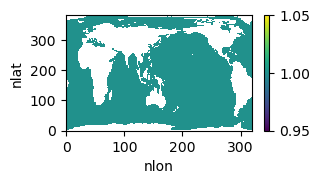

In [ ]:
### third, use the REGION_MASK variable and the ones array to create a land mask
ones = ones.where(ds_grid.REGION_MASK>0)
ones.plot(figsize=(3,1.5))

In [ ]:
### forth, get the major basins mask 
major_basins = xr.open_dataset('/glade/work/kristenk/ocean_masks/major_basins.nc')

major_basins = major_basins.basin.values
major_basins = xr.DataArray(major_basins, dims=('nlat','nlon'))

### Get the model FOSI run

In [ ]:
case = 'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.4p2z.002branch'
path = '/glade/campaign/cesm/development/bgcwg/projects/CESM2-OMIP2-like-4p2z-run/'+case+'/ocn/proc/tseries/month_1/'

In [ ]:
variables = ['IFRAC','HMXL','diatChl','spChl','coccoChl','diazChl','TEMP']

In [ ]:
def preprocess(ds):
    ds = ds.isel(z_t=0)
    ds = ds.isel(z_t_150m=0)
    return ds

In [ ]:
ds_fosi = xr.Dataset()

for var in variables:
    
    print('starting on ', var)
    ################ FOSI
    
    #ds_tmp = xr.open_dataset(path+case+'.pop.h.'+var+'.??????-??????.nc')
    #ds_tmp['time'] = time
    
    files = sorted(glob(f'{path}/{case}.pop.h.{var}.??????-??????.nc'))       
    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, concat_dim="time",
                       drop_variables=["transport_components", "transport_regions"], decode_times=True, preprocess=preprocess, combine='nested')

    keep_vars=['z_t','z_t_150m','time_bound','dz','TLAT','TLONG','time','KMT'] + [var]

    ds_tmp = ds_tmp.drop_vars([v for v in ds_tmp.variables if v not in keep_vars])
        
    ds_fosi = xr.merge([ds_fosi,ds_tmp], compat='override')

starting on  IFRAC
starting on  HMXL
starting on  diatChl
starting on  spChl
starting on  coccoChl
starting on  diazChl
starting on  TEMP


### Make a mean of the time bounds (CESM-specific)

In [ ]:
ds_fosi["time"] = ds_fosi.time_bound.compute().mean(dim="d2")

### trim to the satellite period since 2003

In [ ]:
ds_fosi.time[540:768]

<xarray.DataArray 'time' (time: 228)> Size: 2kB
array([cftime.DatetimeNoLeap(2003, 1, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2003, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2003, 3, 16, 12, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeNoLeap(2021, 10, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 11, 16, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2021, 12, 16, 12, 0, 0, 0, has_year_zero=True)],
      shape=(228,), dtype=object)
Coordinates:
  * time      (time) object 2kB 2003-01-16 12:00:00 ... 2021-12-16 12:00:00
    z_t       float32 4B 500.0
    z_t_150m  float32 4B 500.0
Attributes:
    long_name:     boundaries for time-averaging interval
    cell_methods:  time: mean

In [ ]:
### slice the data
ds_fosi = ds_fosi.isel(time=slice(540,768))

In [ ]:
ds_fosi.load()

<xarray.Dataset> Size: 787MB
Dimensions:     (time: 228, nlat: 384, nlon: 320, d2: 2)
Coordinates:
  * time        (time) object 2kB 2003-01-16 12:00:00 ... 2021-12-16 12:00:00
    TLAT        (nlat, nlon) float64 983kB -79.22 -79.22 -79.22 ... nan nan nan
    TLONG       (nlat, nlon) float64 983kB 320.6 321.7 322.8 ... nan nan nan
    z_t         float32 4B 500.0
    z_t_150m    float32 4B 500.0
Dimensions without coordinates: nlat, nlon, d2
Data variables:
    IFRAC       (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    KMT         (nlat, nlon) float64 983kB 0.0 0.0 0.0 0.0 ... nan nan nan nan
    dz          float32 4B 1e+03
    time_bound  (time, d2) object 4kB 2003-01-01 00:00:00 ... 2022-01-01 00:0...
    HMXL        (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    diatChl     (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    spChl       (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    coccoChl    (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    diazChl     (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan
    TEMP        (time, nlat, nlon) float32 112MB nan nan nan nan ... nan nan nan

In [ ]:
import psutil
import os

# Get current process memory usage in MB
process = psutil.Process(os.getpid())
mem_info = process.memory_info()
print(f"Memory usage: {mem_info.rss / 1024 ** 3:.2f} GB")


Memory usage: 1.34 GB


# A few precalculations....

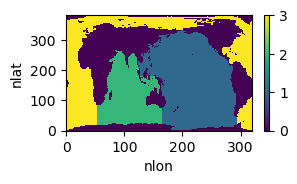

In [ ]:
major_basins.plot(figsize=(3,1.5))

### Assign basins

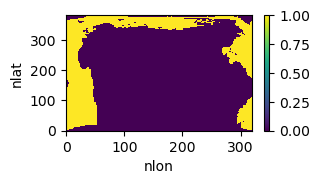

In [ ]:
Atlantic = ones.where(major_basins == 3, other=0)
#.where(major_basins.basin == 3) #ones.where(ds_grid.REGION_MASK >= 5, other=0).where(ds_grid.REGION_MASK<10, other=0)
Atlantic.plot(figsize=(3,1.5))

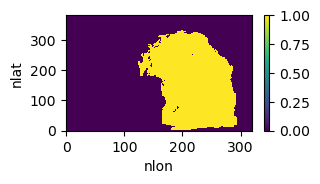

In [ ]:
Pacific = ones.where(major_basins == 1, other=0)
Pacific.plot(figsize=(3,1.5))

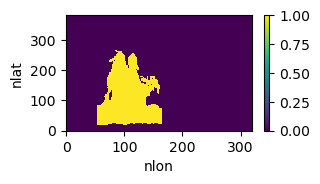

In [ ]:
Indian = ones.where(major_basins == 2, other=0)
Indian.plot(figsize=(3,1.5))

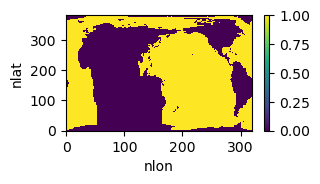

In [ ]:
Atlantic_Pacific = Atlantic + Pacific
Atlantic_Pacific.plot(figsize=(3,1.5))

# Calc Heatwaves

In [ ]:
import mhw_utils as mhw
import pickle
import pandas as pd
from datetime import date

In [ ]:
# ds = ds_fosi[['TEMP']].load()

# lat_str = 'nlat'
# lon_str = 'nlon'

In [ ]:


# ds#['TEMP']#.load()

In [ ]:
ds = ds_fosi[['TEMP']].load()

#ds = ds.chunk({'time':-1, 'lat':1, 'lon':-1})
#ds = ds.chunk({'time':-1})
# ds = ds.chunk({'time':-1})
# ds = ds.sel(nlat=slice(150,200), nlon=slice(200, 250))
# major_basins_test = major_basins.sel(nlat=slice(150,200), nlon=slice(200, 250))
# ds = ds.sel(time = slice('1982-01-01', '2018-12-31'))

time_ordinal = np.array([int(x.toordinal()) for x in ds.time.values])  #Convert to ordinal because that is the time format the mhw function expects
ds['time_ordinal'] = ('time', time_ordinal)
# ds = ds.swap_dims({'time': 'time_ordinal'}).transpose('nlat', 'nlon', 'time_ordinal')

empty_dict={'time_start': [np.nan],
            'time_end': [np.nan],
            'time_peak': [np.nan],
            'date_start': [np.nan],
            'date_end': [np.nan],
            'date_peak': [np.nan],
            'index_start': [np.nan],
            'index_end': [np.nan],
            'index_peak': [np.nan],
            'duration': [np.nan],
            'duration_moderate': [np.nan],
            'duration_strong': [np.nan],
            'duration_severe': [np.nan],
            'duration_extreme': [np.nan],
            'intensity_max': [np.nan],
            'intensity_mean': [np.nan],
            'intensity_var': [np.nan],""
            'intensity_cumulative': [np.nan],
            'intensity_max_relThresh': [np.nan],
            'intensity_mean_relThresh': [np.nan],
            'intensity_var_relThresh': [np.nan],
            'intensity_cumulative_relThresh': [np.nan],
            'intensity_max_abs': [np.nan],
            'intensity_mean_abs': [np.nan],
            'intensity_var_abs': [np.nan],
            'intensity_cumulative_abs': [np.nan],
            'category': ['nan'],
            'rate_onset': [np.nan],
            'rate_decline': [np.nan],
            'n_events': [np.nan]
            }

# @dask.delayed  #Wrapping the marineheatwave package into a delayed function
def mhw_ufunc(one_sst, basin_mask, time_ord=None, empty_dict=None):
    # print(one_sst, basin_mask)
    # print(time_ord)
    if int(basin_mask)==0:
        mhw_obj = empty_dict
    else:  #where ocean
        mhw_obj,_ = mhw.detect(time_ord,one_sst)

    # mhw_obj = one_sst + 100
        
    # print(mhw_obj)
    return mhw_obj

# ds_landmask = major_basins.where(major_basins!=0)  #Dataset of nans over land

# ds['basin_mask'] = major_basins

result = xr.apply_ufunc(
    mhw_ufunc,
    ds['TEMP'],
    major_basins,
    kwargs={'time_ord':ds['time_ordinal'].values, 'empty_dict': empty_dict},
    input_core_dims=[['time'],[]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    # output_dtypes=[dict],
    on_missing_core_dim='copy'
)


# lon_list = {}
# lat_list = {}
# loc_list = []
# for jj, kk in enumerate(ds_landmask[lat_str].values):  #Step through lats
#     results = []
#     print(jj)
#     ds_landmask_lons = ds_landmask.sel(nlat = kk)
#     lons = ds_landmask_lons[lon_str]  #List of lons for this lat
#     for ii,ll in enumerate(ds_landmask_lons[lon_str].values):
#         print(jj,ll)
#         if ~np.isnan(ds_landmask_lons.isel(nlon = ii)):  #Only land points
#             print('   Land ho!')
#             sample = ds_landmask_lons.sel(nlon = ll)

#             mhw_obj = mhw_wrapper(time_ordinal, sample)

#             results.append(mhw_obj[0])
#         # else:
#             # results.append(xr.full_like(ds_landmask, np.nan))
               
#     print(results)
#     all_output = dask.compute(*results)
#     print((all_output))
#     if np.size(all_output)!=0:
#         lons = dask.compute(lons)

#         all_ds = []

#         for ii,listitem in enumerate(all_output[0]):
#             print(ii, listitem)
#             mhw_detect = xr.Dataset()
#             event_1 = listitem['index_start']
#             event = xr.DataArray(np.atleast_1d(event_1), dims = ['event'],\
#                                 coords = {'event':np.atleast_1d(event_1)})

#             for key in listitem.keys():
#                 if key not in ['index_start', 'date_start', 'date_end', 'date_peak', 'category'] :
#                     mhw_detect[key] = xr.DataArray(listitem[key], name = key, \
#                     dims = ['event'], coords = {'event':event} )
            
#             all_ds.append(mhw_detect) 

#         t1 = xr.Dataset()
#         t1[key] = listitem[key]
#         new_loc = lons[0]

#         ds_final = xr.concat(all_ds, dim = new_loc.coords['lon'])
#         ds_final = ds_final.assign_coords({'lon':new_loc.coords['lon']})
#         ds_final_unst = ds_final.unstack()

#         # ds_final.to_netcdf(save_dir + "mhw_metrics_" + str(jj).zfill(5) + ".zarr")
#         ds_final_unst.to_netcdf(save_dir+"mhw_metrics.nc")
#     #somehow dask delayed parallelizes for loops when operating on a delayed function
#     #seems like magic to me...

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 

In [ ]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (time_ordinal: 228, nlat: 50, nlon: 50)
Coordinates:
  * time_ordinal  (time_ordinal) int64 2kB 731110 731140 ... 737984 738014
    TLAT          (nlat, nlon) float64 20kB -9.75 -9.75 -9.75 ... 3.336 3.335
    TLONG         (nlat, nlon) float64 20kB 185.6 186.7 187.8 ... 239.6 240.7
    time          (time_ordinal) object 2kB 2003-01-16 12:00:00 ... 2021-12-1...
    z_t           float32 4B 500.0
    z_t_150m      float32 4B 500.0
Dimensions without coordinates: nlat, nlon
Data variables:
    TEMP          (nlat, nlon, time_ordinal) float32 2MB 29.59 29.69 ... 24.76

In [ ]:
result.load()

<xarray.DataArray 'TEMP' (nlat: 50, nlon: 50)> Size: 20kB
array([[{'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mean_abs': [], 'intensity_var_abs': [], 'intensity_cumulative_abs': [], 'category': [], 'rate_onset': [], 'rate_decline': [], 'n_events': 0},
        {'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mean_abs': [], 'intensity_var_abs': [], 'intensity_cumulative_abs': [], 'category': [], 'rate_onset': [], 'rate_decline': [], 'n_events': 0},
        {'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mean_abs': [], 'intensity_var_abs': [], 'intensity_cumulative_abs': [], 'category': [], 'rate_onset': [], 'rate_decline': [], 'n_events': 0},
        ...,
        {'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mean_abs': [], 'intensity_var_abs': [], 'intensity_cumulative_abs': [], 'category': [], 'rate_onset': [], 'rate_decline': [], 'n_events': 0},
        {'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mean_abs': [], 'intensity_var_abs': [], 'intensity_cumulative_abs': [], 'category': [], 'rate_onset': [], 'rate_decline': [], 'n_events': 0},
        {'time_start': [], 'time_end': [], 'time_peak': [], 'date_start': [], 'date_end': [], 'date_peak': [], 'index_start': [], 'index_end': [], 'index_peak': [], 'duration': [], 'duration_moderate': [], 'duration_strong': [], 'duration_severe': [], 'duration_extreme': [], 'intensity_max': [], 'intensity_mean': [], 'intensity_var': [], 'intensity_cumulative': [], 'intensity_max_relThresh': [], 'intensity_mean_relThresh': [], 'intensity_var_relThresh': [], 'intensity_cumulative_relThresh': [], 'intensity_max_abs': [], 'intensity_mea

In [ ]:
ds

<xarray.Dataset> Size: 114MB
Dimensions:   (time: 228, nlat: 384, nlon: 320)
Coordinates:
  * time      (time) object 2kB 2003-01-16 12:00:00 ... 2021-12-16 12:00:00
    TLAT      (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    z_t       float32 4B 500.0
    z_t_150m  float32 4B 500.0
Dimensions without coordinates: nlat, nlon
Data variables:
    TEMP      (time, nlat, nlon) float32 112MB dask.array<chunksize=(228, 384, 320), meta=np.ndarray>

In [ ]:
dummy_dict2 = pickle.load(open('../tools/empty_mhw.pickle','rb'))

In [ ]:
dummy_dict2

{'time_start': [np.int64(-99)],
 'time_end': [np.int64(-99)],
 'time_peak': [np.int64(-99)],
 'date_start': [np.int64(-99)],
 'date_end': [np.int64(-99)],
 'date_peak': [np.int64(-99)],
 'index_start': [np.int64(-99)],
 'index_end': [np.int64(-99)],
 'index_peak': [np.int64(-99)],
 'duration': [np.int64(-99)],
 'duration_moderate': [np.int64(-99)],
 'duration_strong': [np.int64(-99)],
 'duration_severe': [np.int64(-99)],
 'duration_extreme': [np.int64(-99)],
 'intensity_max': [np.int64(-99)],
 'intensity_mean': [np.int64(-99)],
 'intensity_var': [np.int64(-99)],
 'intensity_cumulative': [np.int64(-99)],
 'intensity_max_relThresh': [np.int64(-99)],
 'intensity_mean_relThresh': [np.int64(-99)],
 'intensity_var_relThresh': [np.int64(-99)],
 'intensity_cumulative_relThresh': [np.int64(-99)],
 'intensity_max_abs': [np.int64(-99)],
 'intensity_mean_abs': [np.int64(-99)],
 'intensity_var_abs': [np.int64(-99)],
 'intensity_cumulative_abs': [np.int64(-99)],
 'category': ['nan'],
 'rate_onset': 